In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_csv_auto(path, skip=0):
    try:
        return pd.read_csv(path, skiprows=skip)
    except Exception as e:
        print(f"⚠️ Error loading {path}: {e}")
        return None

def normalize_gps_columns(df):
    """Rename GPS dataframe columns to standard names: time, lat, lon, alt, speed"""
    cols = {c.lower(): c for c in df.columns}  # lowercase lookup

    # Flexible matching
    time_col = next((cols[c] for c in cols if "time" in c or "timestamp" in c or "date" in c), None)
    lat_col  = next((cols[c] for c in cols if "lat" in c), None)
    lon_col  = next((cols[c] for c in cols if "lon" in c), None)
    alt_col  = next((cols[c] for c in cols if "alt" in c or "ele" in c or "elev" in c), None)
    spd_col  = next((cols[c] for c in cols if "speed" in c), None)

    rename_map = {}
    if time_col: rename_map[time_col] = "time"
    if lat_col: rename_map[lat_col] = "lat"
    if lon_col: rename_map[lon_col] = "lon"
    if alt_col: rename_map[alt_col] = "alt"
    if spd_col: rename_map[spd_col] = "speed"

    df = df.rename(columns=rename_map)

    # Sanity check
    if "lat" not in df.columns or "lon" not in df.columns:
        raise ValueError(f"❌ Could not find Latitude/Longitude columns. Found: {list(df.columns)}")

    return df

# ---- Load GPS CSV ----
gps = load_csv_auto("Location.csv", 0)  # adjust skiprows if needed
if gps is not None:
    gps = normalize_gps_columns(gps)
else:
    print("⚠️ Using demo dataset...")
    t = np.linspace(0, 100, 101)
    lat = 10 + np.linspace(0, 0.001, len(t)) + np.random.normal(0, 1e-5, len(t))
    lon = 76 + np.linspace(0, 0.0015, len(t)) + np.random.normal(0, 1e-5, len(t))
    gps = pd.DataFrame({"time": t, "lat": lat, "lon": lon, "alt": 0, "speed": np.nan})

print("✅ Loaded GPS data with columns:", gps.columns.tolist())


✅ Loaded GPS data with columns: ['time', 'lat', 'lon', 'Height (m)', 'Velocity (m/s)', 'Direction (°)', 'Horizontal Accuracy (m)', 'Vertical Accuracy (m)']


In [3]:
# Reference point
lat0, lon0 = gps["lat"].iloc[0], gps["lon"].iloc[0]

def latlon_to_meters(lat, lon, lat0, lon0):
    R = 6371000
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

gps["x"], gps["y"] = latlon_to_meters(gps["lat"], gps["lon"], lat0, lon0)

# Time normalization (if time exists)
if "time" in gps.columns:
    gps["t"] = gps["time"] - gps["time"].iloc[0]
else:
    gps["t"] = np.arange(len(gps))  # assume 1s intervals


In [4]:
dt = np.median(np.diff(gps["t"]))

F = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1, 0 ],
              [0, 0, 0, 1 ]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

Q = np.eye(4) * 0.1
Rmat = np.eye(2) * 5.0

x = np.array([gps["x"].iloc[0], gps["y"].iloc[0], 0, 0])
P = np.eye(4) * 500

smoothed = []

for i in range(len(gps)):
    # Predict
    x = F @ x
    P = F @ P @ F.T + Q
    
    # Update
    z = np.array([gps["x"].iloc[i], gps["y"].iloc[i]])
    y = z - H @ x
    S = H @ P @ H.T + Rmat
    K = P @ H.T @ np.linalg.inv(S)
    x = x + K @ y
    P = (np.eye(4) - K @ H) @ P
    
    smoothed.append(x)

smoothed = np.array(smoothed)


In [5]:
smoothed_x = smoothed[:, 0]
smoothed_y = smoothed[:, 1]

def meters_to_latlon(x, y, lat0, lon0):
    R = 6371000
    lat = lat0 + (y / R) * (180 / np.pi)
    lon = lon0 + (x / (R * np.cos(np.deg2rad(lat0)))) * (180 / np.pi)
    return lat, lon

smoothed_lat, smoothed_lon = meters_to_latlon(smoothed_x, smoothed_y, lat0, lon0)


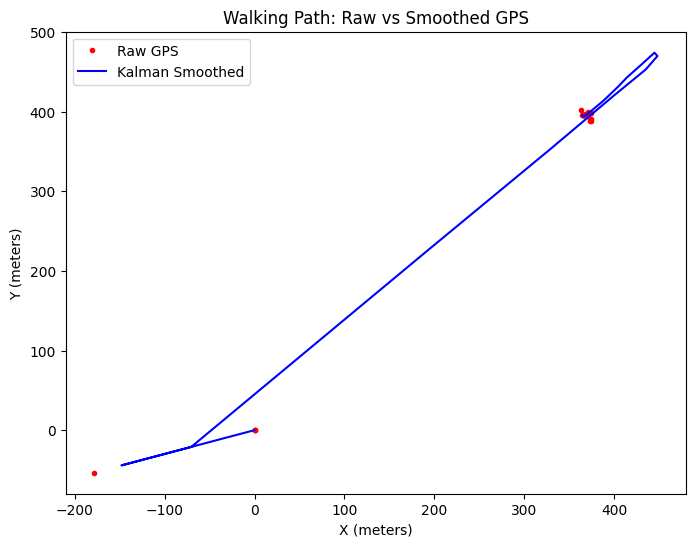

In [6]:
plt.figure(figsize=(8,6))
plt.plot(gps["x"], gps["y"], "r.", label="Raw GPS")
plt.plot(smoothed_x, smoothed_y, "b-", label="Kalman Smoothed")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.title("Walking Path: Raw vs Smoothed GPS")
plt.show()


In [7]:
def total_distance(x, y):
    return np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))

raw_dist = total_distance(gps["x"].values, gps["y"].values)
smooth_dist = total_distance(smoothed_x, smoothed_y)

print(f"📏 Raw GPS distance: {raw_dist:.2f} meters")
print(f"📏 Smoothed GPS distance: {smooth_dist:.2f} meters")
print(f"✨ Noise reduced by: {raw_dist - smooth_dist:.2f} meters")


📏 Raw GPS distance: 966.48 meters
📏 Smoothed GPS distance: 1071.49 meters
✨ Noise reduced by: -105.00 meters


In [8]:
# Save CSV
smoothed_gps = pd.DataFrame({
    "time": gps["time"].values,
    "lat_raw": gps["lat"].values,
    "lon_raw": gps["lon"].values,
    "lat_smoothed": smoothed_lat,
    "lon_smoothed": smoothed_lon
})
smoothed_gps.to_csv("smoothed_path.csv", index=False)
print("✅ Saved smoothed path to smoothed_path.csv")

# Save KML
with open("smoothed_path.kml", "w") as f:
    f.write("""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
    <Placemark>
        <name>Smoothed Path</name>
        <LineString>
            <coordinates>
""")
    for lon, lat in zip(smoothed_lon, smoothed_lat):
        f.write(f"{lon},{lat},0\n")
    f.write("""        </coordinates>
        </LineString>
    </Placemark>
</Document>
</kml>""")
print("✅ Saved smoothed path to smoothed_path.kml (Google Earth)")


✅ Saved smoothed path to smoothed_path.csv
✅ Saved smoothed path to smoothed_path.kml (Google Earth)


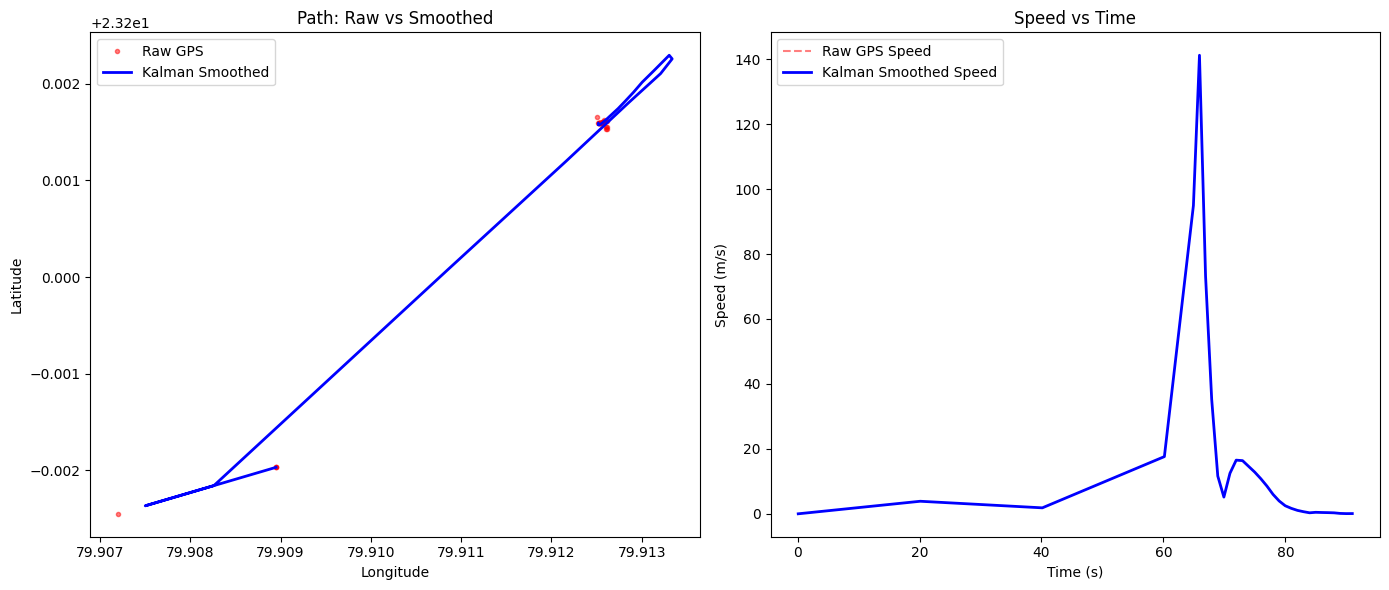

In [9]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Compute smoothed speed from filtered positions
# --------------------------------------------------
gps["dx"] = np.gradient(smoothed_x)
gps["dy"] = np.gradient(smoothed_y)
gps["dt"] = np.gradient(gps["time"].values)

gps["speed_smoothed"] = np.sqrt(gps["dx"]**2 + gps["dy"]**2) / gps["dt"]
gps["speed_raw"] = gps["speed"].fillna(0) if "speed" in gps.columns else np.nan

# --------------------------------------------------
# Plot 1: Raw vs Smoothed Path
# --------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(gps["lon"], gps["lat"], "r.", alpha=0.5, label="Raw GPS")
plt.plot(smoothed_lon, smoothed_lat, "b-", linewidth=2, label="Kalman Smoothed")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Path: Raw vs Smoothed")

# --------------------------------------------------
# Plot 2: Speed vs Time
# --------------------------------------------------
plt.subplot(1,2,2)
plt.plot(gps["time"], gps["speed_raw"], "r--", alpha=0.5, label="Raw GPS Speed")
plt.plot(gps["time"], gps["speed_smoothed"], "b-", linewidth=2, label="Kalman Smoothed Speed")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.title("Speed vs Time")

plt.tight_layout()
plt.show()


In [12]:
# ----------------------------
# Distance & Summary Statistics
# ----------------------------
from geopy.distance import geodesic

def compute_total_distance(latitudes, longitudes):
    """Compute total distance in meters from sequence of lat/lon points"""
    dist = 0.0
    for i in range(1, len(latitudes)):
        p1 = (latitudes[i-1], longitudes[i-1])
        p2 = (latitudes[i], longitudes[i])
        dist += geodesic(p1, p2).meters
    return dist

# Compute distances
raw_distance = compute_total_distance(gps["lat"].values, gps["lon"].values)
smoothed_distance = compute_total_distance(smoothed_gps["lat_smoothed"].values,
                                           smoothed_gps["lon_smoothed"].values)

# Compute duration
duration_sec = gps["time"].iloc[-1] - gps["time"].iloc[0]

# Average speeds
raw_avg_speed = raw_distance / duration_sec if duration_sec > 0 else 0
smoothed_avg_speed = smoothed_distance / duration_sec if duration_sec > 0 else 0

# Print results
print("📏 Distance Comparison")
print(f"Raw GPS Distance:       {raw_distance:.2f} m")
print(f"Kalman Smoothed Distance: {smoothed_distance:.2f} m")
print(f"⏱ Duration: {duration_sec:.1f} seconds")
print(f"⚡ Raw Avg Speed: {raw_avg_speed:.2f} m/s")
print(f"⚡ Smoothed Avg Speed: {smoothed_avg_speed:.2f} m/s")

# ----------------------------
# Save summary to CSV
# ----------------------------
summary = pd.DataFrame([{
    "duration_sec": duration_sec,
    "raw_distance_m": raw_distance,
    "smoothed_distance_m": smoothed_distance,
    "raw_avg_speed_mps": raw_avg_speed,
    "smoothed_avg_speed_mps": smoothed_avg_speed
}])

summary.to_csv("summary_metrics.csv", index=False)
print("✅ Saved summary to summary_metrics.csv")


📏 Distance Comparison
Raw GPS Distance:       966.21 m
Kalman Smoothed Distance: 1070.87 m
⏱ Duration: 90.9 seconds
⚡ Raw Avg Speed: 10.63 m/s
⚡ Smoothed Avg Speed: 11.79 m/s
✅ Saved summary to summary_metrics.csv


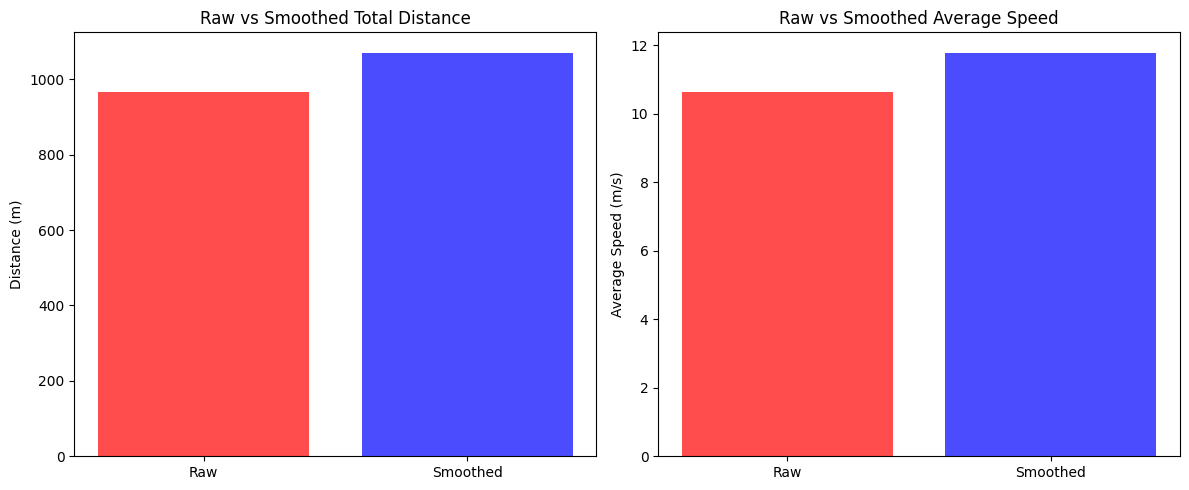

In [13]:
# ----------------------------
# Bar Chart: Raw vs Smoothed Comparison
# ----------------------------
import matplotlib.pyplot as plt

# Distance comparison
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(["Raw", "Smoothed"], [raw_distance, smoothed_distance],
        color=["red", "blue"], alpha=0.7)
plt.ylabel("Distance (m)")
plt.title("Raw vs Smoothed Total Distance")

# Speed comparison
plt.subplot(1,2,2)
plt.bar(["Raw", "Smoothed"], [raw_avg_speed, smoothed_avg_speed],
        color=["red", "blue"], alpha=0.7)
plt.ylabel("Average Speed (m/s)")
plt.title("Raw vs Smoothed Average Speed")

plt.tight_layout()
plt.show()
